# Simulate data using behavioral model and perform parameter recovery

There are 3 models with different parameter combinations:

1. <b>The Bayesian model (Schwöbel et al. 2021):</b> \
   <b>a.</b> With 3 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, and a decision temparature $\beta$. \
   <b>b.</b> With 4 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, a decision temparature $\beta$, and a habitual tendency $h$.
2. <b>A newer MF/MB version that is better for fitting (Otto et al. 2013):</b> \
<b>Note:</b> This is not quite the original version, as the Q-values in the original work did not converge to the true expected values. Instead, I implemented a "bug-fixed" version.\
   <b>a.</b> With 4 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$$, and a repetition/perserveration parameter $p$. \
3. <b>The original model-free/model-based (MF/MB) model (Daw et al. 2005, 2011):</b> \
   <b>a.</b> With 4 parameters: a weighting parameters $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a weighting parameter $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, a dicount factor $\lambda$, and a repetition/perserveration parameter $p$.

Tell python that the code in the submodule is code that we want to import and run

In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','code','BalancingControl'))

import two_stage_utils as tu
import inference as inf
import inference_utils as iu

torch threads 1


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device cpu
torch threads 1


Other imports that we need for simulation, inference, and plotting

In [2]:
import torch
import pyro

import os
from scipy.io import loadmat
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
import json
import gc
import pickle

Where second stage random walks from the experiment are stored

In [3]:
Rho_data_fname = os.path.join("experiment", "dawrandomwalks.mat")

Define where results should be saved

In [4]:
results_folder = os.path.join(current_dir, "results")
simulation_folder = os.path.join(results_folder, "simulations")
recovery_folder = os.path.join(results_folder, "recovery")

mask_file_name = "mask.txt"
processed_data_folder = os.path.join("processed_data")
mask_file = os.path.join(processed_data_folder, mask_file_name)

#### Global experiment parameters

In [5]:
# number of simulated agents/participants
n_agents = 188

In [6]:
trials =  201#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
with open(mask_file, "rb") as f:
    all_mask = pickle.load(f)
# simulations will be done with the same missing actions as in the data.
exp_mask = torch.tensor(all_mask).permute((1,0))
p_valid = exp_mask.sum()/(exp_mask.shape[0]*exp_mask.shape[1])
print(p_valid)

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_valid, "mask": exp_mask}

tensor(0.9766)


/tmp/ipykernel_159102/1544998221.py:15: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  exp_mask = torch.tensor(all_mask).permute((1,0))


Define states and transition matrices

In [7]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

Load and plot reward probabilities

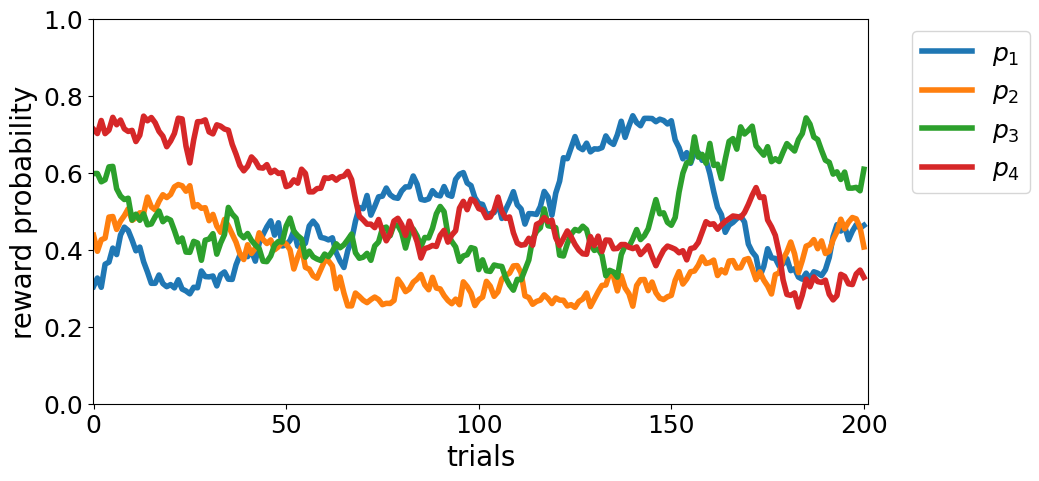

In [8]:
rew_probs = loadmat(Rho_data_fname)['dawrandomwalks']
assert trials==rew_probs.shape[-1]

Rho = torch.zeros((trials, nr, ns))

Rho[:,1,:never_reward] = 0.
Rho[:,0,:never_reward] = 1.

Rho[:,1,never_reward:never_reward+2] = torch.from_numpy(rew_probs[0,:,:]).permute((1,0))
Rho[:,0,never_reward:never_reward+2] = torch.from_numpy(1-rew_probs[0,:,:]).permute((1,0))

Rho[:,1,never_reward+2:] = torch.from_numpy(rew_probs[1,:,:]).permute((1,0))
Rho[:,0,never_reward+2:] = torch.from_numpy(1-rew_probs[1,:,:]).permute((1,0))

plt.figure(figsize=(10,5))
for i in range(4):
    plt.plot(Rho[:,1,3+i], label="$p_{}$".format(i+1), linewidth=4)
plt.ylim([0,1])
plt.yticks(torch.arange(0,1.1,0.2),fontsize=18)
plt.ylabel("reward probability", fontsize=20)
plt.xlim([-0.1, trials+0.1])
plt.xticks(range(0,trials+1,50),fontsize=18)
plt.xlabel("trials", fontsize=20)
plt.legend(fontsize=18, bbox_to_anchor=(1.04,1))
plt.savefig(os.path.join(results_folder, "twostep_prob.svg"),dpi=300)
plt.show()

# add to parameter dict
global_experiment_parameters["Rho"] = Rho

Now we can start :) 

### 2. MF/MB:
### 2.a 4 parameter version

Simulation pre-setup

In [9]:
# set parameters and their names
learn_prior = False

use_orig = False

use_p = False
restrict_alpha = False
max_dt = 6

n_pars = 4

prefix = "MFMB"
agnt_str = ""

if use_orig:
    agnt_str += "_mf_mb_Orig"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    param_ranges = [[0,1], [0,1], [0,8], [0,1]]
else:
    agnt_str += "_mf_mb"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(agent_type)
fname_base = agent_type+"_simulation_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(simulation_folder,fname_base[:-1])

MFMB_4pars_mf_mb
MFMB_4pars_mf_mb_simulation_


<b>Decide</b> for running or loading simulated data

In [10]:
run_simulation = True

<b>Either:</b> (re)run simulations, save parameter and behavior

In [11]:
if run_simulation:
    # make directory if it doesnt exist
    if fname_base[:-1] not in os.listdir(simulation_folder):
        os.mkdir(base_dir)
    
    # choose whether olf simulations in this folder should be deleted.
    remove_old = False

    print("simulating "+str(n_agents)+" agents...\nrandomly generating true parameter values...")
    stayed_arr, true_vals, data = tu.run_mfmb_simulations(n_agents, agent_type, n_pars, learn_prior, use_orig, use_p, restrict_alpha, min_alpha, fname_base, base_dir, 
                                                          **global_experiment_parameters, max_dt=max_dt, remove_old=remove_old)

simulating 188 agents...
randomly generating true parameter values...
{'subject': tensor([0]), 'discount': tensor([0.4680]), 'learning rate': tensor([0.3215]), 'mf weight': tensor([2.8273]), 'mb weight': tensor([0.1838]), 'prior lr': tensor([0.]), 'prior weight': tensor([0.]), 'repetition': tensor([0.]), 'learn_prior': False, 'max dt': 6, 'min learning rate': 0}


{'subject': tensor([1]), 'discount': tensor([0.1696]), 'learning rate': tensor([0.0859]), 'mf weight': tensor([2.7405]), 'mb weight': tensor([4.3650]), 'prior lr': tensor([0.]), 'prior weight': tensor([0.]), 'repetition': tensor([0.]), 'learn_prior': False, 'max dt': 6, 'min learning rate': 0}


{'subject': tensor([2]), 'discount': tensor([0.1312]), 'learning rate': tensor([0.2008]), 'mf weight': tensor([5.3658]), 'mb weight': tensor([0.9046]), 'prior lr': tensor([0.]), 'prior weight': tensor([0.]), 'repetition': tensor([0.]), 'learn_prior': False, 'max dt': 6, 'min learning rate': 0}


{'subject': tensor([3]), 'discount': tensor([0.8926]), 'learning rate': tensor([0.5304]), 'mf weight': tensor([0.4296]), 'mb weight': tensor([0.3449]), 'prior lr': tensor([0.]), 'prior weight': tensor([0.]), 'repetition': tensor([0.]), 'learn_prior': False, 'max dt': 6, 'min learning rate': 0}


{'subject': tensor([4]), 'discount': tensor([0.4406]), 'learning rate': tensor([0.7885]), 'mf weight': tensor([3.5801]), 'mb weight': tensor([2.5253]), 'prior lr': tensor([0.]), 'prior weight': tensor([0.]), 'repetition': tensor([0.]), 'learn_prior': False, 'max dt': 6, 'min learning rate': 0}


...

{'subject': tensor([183]), 'discount': tensor([0.9026]), 'learning rate': tensor([0.5352]), 'mf weight': tensor([3.7584]), 'mb weight': tensor([2.9492]), 'prior lr': tensor([0.]), 'prior weight': tensor([0.]), 'repetition': tensor([0.]), 'learn_prior': False, 'max dt': 6, 'min learning rate': 0}


{'subject': tensor([184]), 'discount': tensor([0.3250]), 'learning rate': tensor([0.9755]), 'mf weight': tensor([2.2503]), 'mb weight': tensor([0.6059]), 'prior lr': tensor([0.]), 'prior weight': tensor([0.]), 'repetition': tensor([0.]), 'learn_prior': False, 'max dt': 6, 'min learning rate': 0}


{'subject': tensor([185]), 'discount': tensor([0.7776]), 'learning rate': tensor([0.1997]), 'mf weight': tensor([0.4206]), 'mb weight': tensor([3.6399]), 'prior lr': tensor([0.]), 'prior weight': tensor([0.]), 'repetition': tensor([0.]), 'learn_prior': False, 'max dt': 6, 'min learning rate': 0}


{'subject': tensor([186]), 'discount': tensor([0.5924]), 'learning rate': tensor([0.1612]), 'mf weight': tensor([5.5270]), 'mb weight': tensor([0.9542]), 'prior lr': tensor([0.]), 'prior weight': tensor([0.]), 'repetition': tensor([0.]), 'learn_prior': False, 'max dt': 6, 'min learning rate': 0}


{'subject': tensor([187]), 'discount': tensor([0.0258]), 'learning rate': tensor([0.0649]), 'mf weight': tensor([0.4726]), 'mb weight': tensor([2.8848]), 'prior lr': tensor([0.]), 'prior weight': tensor([0.]), 'repetition': tensor([0.]), 'learn_prior': False, 'max dt': 6, 'min learning rate': 0}


<b>Or:</b> load stored simulation results

In [12]:
if not run_simulation:
    print("loading simulated outputs...")
    
    stayed_arr, true_vals, data = tu.load_simulation_outputs(base_dir, agent_type)

    n_true = true_vals["subject"].max() + 1
    n_data = data["subject"].max() + 1

    assert n_true == n_data == n_agents, f"the numbers of agents dont match! They are: {n_true}, {n_data}, {n_agents}. Probably rerun simulations to fix."

    print("true values are:")
    print(true_vals)

Plot simulated stay probability

/tmp/ipykernel_159102/3682874209.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(bar_names, rotation=45, horizontalalignment='right', fontsize=16)


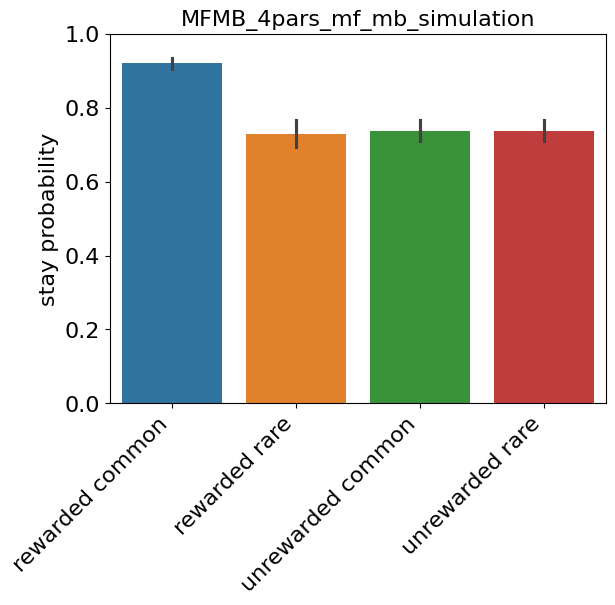

In [13]:
bar_names = ["rewarded common", "rewarded rare", "unrewarded common", "unrewarded rare"]

plt.figure()
g = sns.barplot(data=stayed_arr)
g.set_xticklabels(bar_names, rotation=45, horizontalalignment='right', fontsize=16)
plt.ylim([0,1])
plt.yticks(torch.arange(0,1.1,0.2),fontsize=16)
plt.ylabel("stay probability", fontsize=16)
plt.title(fname_base[:-1], fontsize=16)
plt.savefig(os.path.join(base_dir,"simulated_stay_probs.svg"),dpi=300)
plt.show()

Calculate MF/MB scores from behavior

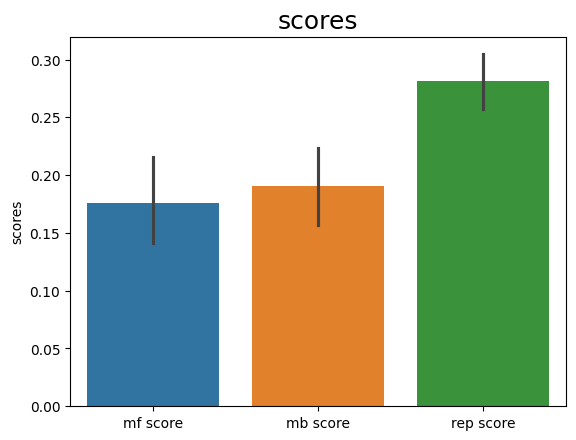

In [14]:
plot_scores_dists = False

mf_score = stayed_arr[:,0] + stayed_arr[:,1] - stayed_arr[:,2] - stayed_arr[:,3]

mb_score = stayed_arr[:,0] - stayed_arr[:,1] - stayed_arr[:,2] + stayed_arr[:,3]

rep_score = stayed_arr.sum(dim=1)/4 - 0.5

scores_df = pd.DataFrame({'mf score': mf_score, 'mb score': mb_score, "rep score": rep_score})

plt.figure()
g = sns.barplot(data=scores_df)
#plt.ylim([0,0.5])
# plt.yticks(np.arange(0,1.1,0.2),fontsize=16)
plt.title("scores", fontsize=18)
plt.ylabel("scores")
plt.show()

if plot_scores_dists:

    plt.figure()
    sns.displot(data=scores_df, x="mf score", kde=True, binrange=[-0.75,1.25], bins=20)
    plt.xlim([-0.75,1.5])
    #plt.ylim([0,0.5])
    # plt.yticks(np.arange(0,1.1,0.2),fontsize=16)
    plt.title("mf scores", fontsize=16)
    plt.ylabel("count")
    plt.show()

    plt.figure()
    sns.displot(data=scores_df, x="mb score", kde=True, binrange=[-0.75,1.25], bins=20)
    plt.xlim([-0.75,1.5])
    # plt.yticks(np.arange(0,1.1,0.2),fontsize=16)
    plt.title("mb scores", fontsize=16)
    plt.ylabel("count")
    plt.show()

    plt.figure()
    sns.displot(data=scores_df, x="rep score", kde=True, binrange=[-0.75,1.25], bins=20)
    plt.xlim([-0.75,1.5])
    # plt.yticks(np.arange(0,1.1,0.2),fontsize=16)
    plt.title("repetition scores", fontsize=16)
    plt.ylabel("count")
    plt.show()

Check for correlations in the sampled true values. This is important if one finds correlations in the inferred values.

Correlations between truw values


<Figure size 640x480 with 0 Axes>

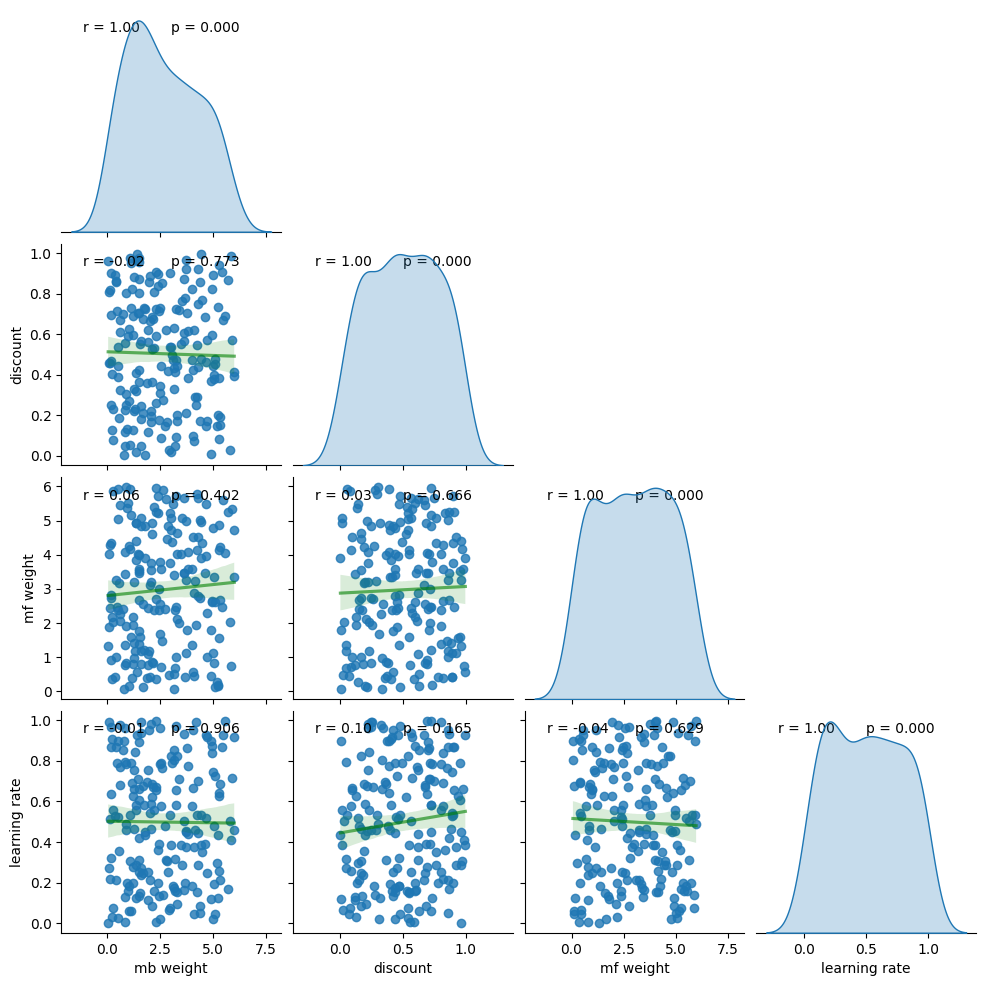

In [15]:
plot_true_correlations = True

if plot_true_correlations:

    print("Correlations between truw values")

    true_vals_df = pd.DataFrame()

    for name in param_names:
        trues = []
        for i in range(n_agents):
            trues.append(true_vals[name][true_vals['subject']==i])

        true_vals_df[name] = torch.tensor(trues)


    plt.figure()
    vars_of_interest = param_names
    f = sns.pairplot(data=true_vals_df, kind='reg', diag_kind="kde", corner=True,
                     plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                     x_vars=vars_of_interest, y_vars=vars_of_interest)
    f.map(tu.annot_corrfunc)
    plt.savefig(os.path.join(base_dir, fname_base+"_pairplot_true_vals_corr.svg"))
    plt.show()

#### Inference

Inference pre-setup

In [16]:
# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_recovery_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(recovery_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(recovery_folder):
    os.mkdir(base_dir)

# how many inference steps
num_steps = 600

MFMB_4pars_mf_mb_recovery_


<b>Decide</b> for running or loading inference

In [17]:
run_inference = True

<b>Either:</b> Set up agent and inference. Run main inference loop, plot intermediate and end results

analyzing 188 data sets
this is inference using <class 'inference.GeneralGroupInference'>
taking steps 1 to 100 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 45988.02:   0%|          | 0/100 [00:08<?, ?it/s]

Mean ELBO 45988.02:   1%|          | 1/100 [00:08<14:11,  8.60s/it]

Mean ELBO 45045.38:   1%|          | 1/100 [00:14<14:11,  8.60s/it]

...

Mean ELBO 28215.85:  98%|█████████▊| 98/100 [10:59<00:14,  7.01s/it]

Mean ELBO 28215.85:  99%|█████████▉| 99/100 [10:59<00:06,  6.98s/it]

Mean ELBO 28172.27:  99%|█████████▉| 99/100 [11:06<00:06,  6.98s/it]

Mean ELBO 28172.27: 100%|██████████| 100/100 [11:06<00:00,  6.97s/it]

Mean ELBO 28172.27: 100%|██████████| 100/100 [11:06<00:00,  6.66s/it]

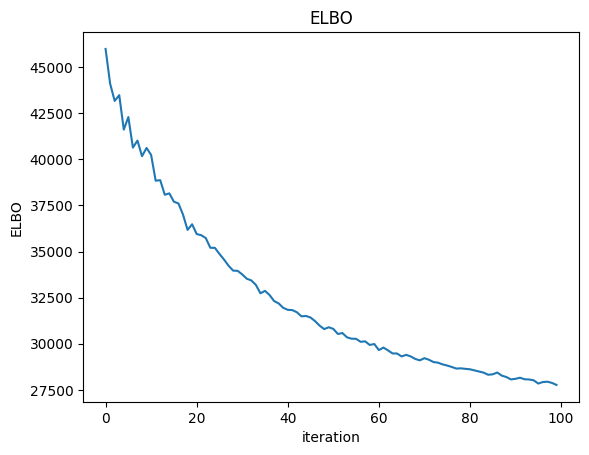

taking steps 101 to 200 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 27719.25:   0%|          | 0/100 [00:06<?, ?it/s]

Mean ELBO 27719.25:   1%|          | 1/100 [00:06<11:24,  6.91s/it]

Mean ELBO 27728.25:   1%|          | 1/100 [00:13<11:24,  6.91s/it]

...

Mean ELBO 26292.28:  98%|█████████▊| 98/100 [11:26<00:13,  6.89s/it]

Mean ELBO 26292.28:  99%|█████████▉| 99/100 [11:26<00:06,  6.94s/it]

Mean ELBO 26282.30:  99%|█████████▉| 99/100 [11:33<00:06,  6.94s/it]

Mean ELBO 26282.30: 100%|██████████| 100/100 [11:33<00:00,  6.91s/it]

Mean ELBO 26282.30: 100%|██████████| 100/100 [11:33<00:00,  6.93s/it]

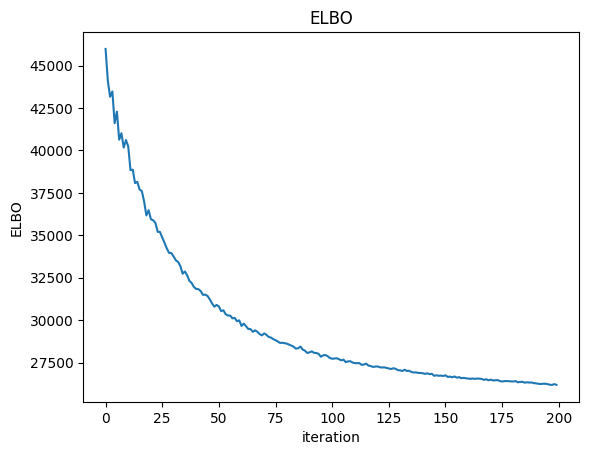

taking steps 201 to 300 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 26182.34:   0%|          | 0/100 [00:06<?, ?it/s]

Mean ELBO 26182.34:   1%|          | 1/100 [00:06<11:30,  6.98s/it]

Mean ELBO 26179.66:   1%|          | 1/100 [00:13<11:30,  6.98s/it]

...

Mean ELBO 25745.28:  98%|█████████▊| 98/100 [11:28<00:13,  6.97s/it]

Mean ELBO 25745.28:  99%|█████████▉| 99/100 [11:28<00:06,  6.95s/it]

Mean ELBO 25742.01:  99%|█████████▉| 99/100 [11:35<00:06,  6.95s/it]

Mean ELBO 25742.01: 100%|██████████| 100/100 [11:35<00:00,  6.94s/it]

Mean ELBO 25742.01: 100%|██████████| 100/100 [11:35<00:00,  6.96s/it]

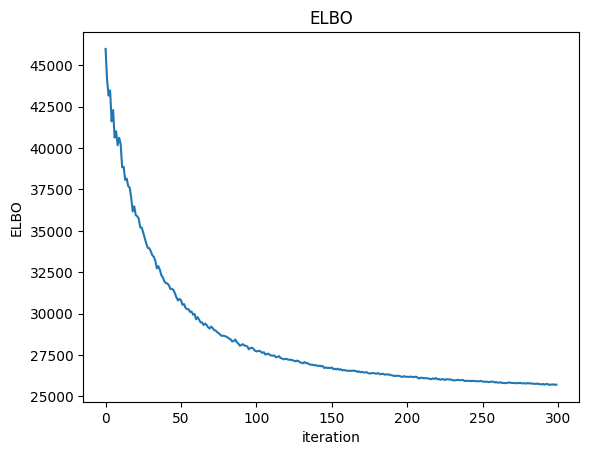

taking steps 301 to 400 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 25722.59:   0%|          | 0/100 [00:06<?, ?it/s]

Mean ELBO 25722.59:   1%|          | 1/100 [00:06<11:21,  6.88s/it]

Mean ELBO 25718.71:   1%|          | 1/100 [00:14<11:21,  6.88s/it]

...

Mean ELBO 25512.36:  98%|█████████▊| 98/100 [11:34<00:14,  7.07s/it]

Mean ELBO 25512.36:  99%|█████████▉| 99/100 [11:34<00:07,  7.08s/it]

Mean ELBO 25510.98:  99%|█████████▉| 99/100 [11:40<00:07,  7.08s/it]

Mean ELBO 25510.98: 100%|██████████| 100/100 [11:40<00:00,  7.05s/it]

Mean ELBO 25510.98: 100%|██████████| 100/100 [11:40<00:00,  7.01s/it]

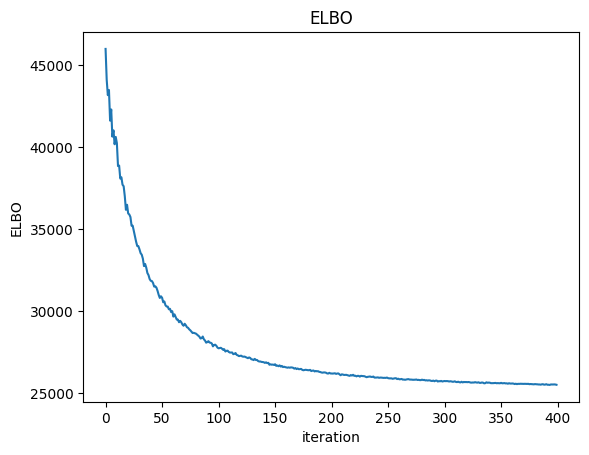

taking steps 401 to 500 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 25502.59:   0%|          | 0/100 [00:07<?, ?it/s]

Mean ELBO 25502.59:   1%|          | 1/100 [00:07<11:37,  7.04s/it]

Mean ELBO 25489.79:   1%|          | 1/100 [00:14<11:37,  7.04s/it]

...

Mean ELBO 25390.55:  98%|█████████▊| 98/100 [11:35<00:14,  7.02s/it]

Mean ELBO 25390.55:  99%|█████████▉| 99/100 [11:35<00:07,  7.01s/it]

Mean ELBO 25389.37:  99%|█████████▉| 99/100 [11:42<00:07,  7.01s/it]

Mean ELBO 25389.37: 100%|██████████| 100/100 [11:42<00:00,  7.01s/it]

Mean ELBO 25389.37: 100%|██████████| 100/100 [11:42<00:00,  7.03s/it]

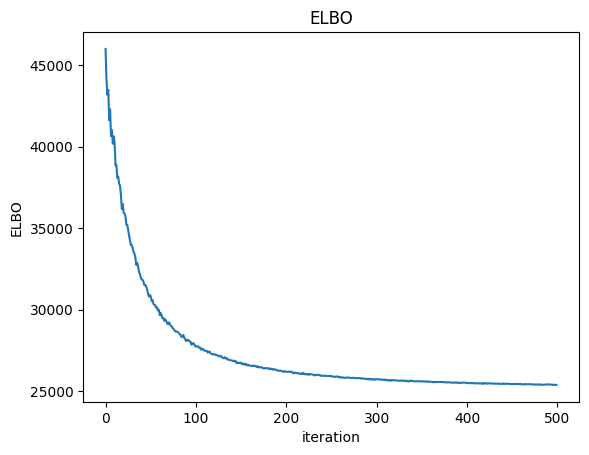

taking steps 501 to 600 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 25383.49:   0%|          | 0/100 [00:06<?, ?it/s]

Mean ELBO 25383.49:   1%|          | 1/100 [00:06<11:29,  6.96s/it]

Mean ELBO 25382.46:   1%|          | 1/100 [00:13<11:29,  6.96s/it]

...

Mean ELBO 25312.08:  98%|█████████▊| 98/100 [11:34<00:14,  7.02s/it]

Mean ELBO 25312.08:  99%|█████████▉| 99/100 [11:34<00:07,  7.03s/it]

Mean ELBO 25311.36:  99%|█████████▉| 99/100 [11:42<00:07,  7.03s/it]

Mean ELBO 25311.36: 100%|██████████| 100/100 [11:42<00:00,  7.03s/it]

Mean ELBO 25311.36: 100%|██████████| 100/100 [11:42<00:00,  7.02s/it]

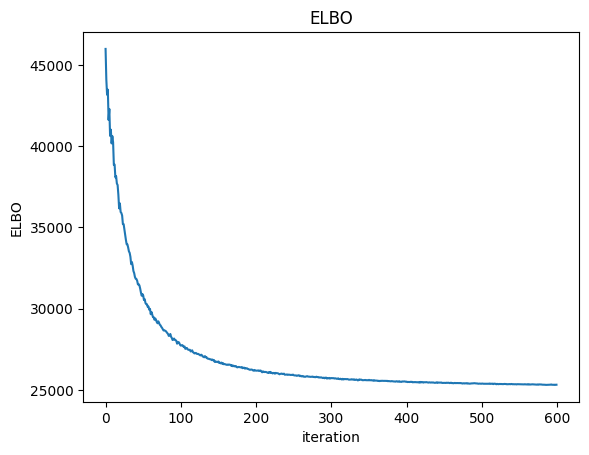

       discount  learning rate  mf weight  mb weight  subject
0      0.532871       0.234929   1.555098   1.110257        0
1      0.411830       0.085666   3.914015   5.183793        1
2      0.954571       0.245814   3.306564   4.284298        2
3      0.353650       0.753806   0.766179   0.609661        3
4      0.462835       0.705630   2.782614   3.785144        4
...         ...            ...        ...        ...      ...
93995  0.891523       0.691208   4.878588   3.899682      183
93996  0.350270       0.853418   1.548482   0.631861      184
93997  0.577284       0.184471   0.645270   4.229926      185
93998  0.659203       0.155532   1.401580   3.588252      186
93999  0.033902       0.062506   0.347739   2.108328      187

[94000 rows x 5 columns]


<Figure size 640x480 with 0 Axes>

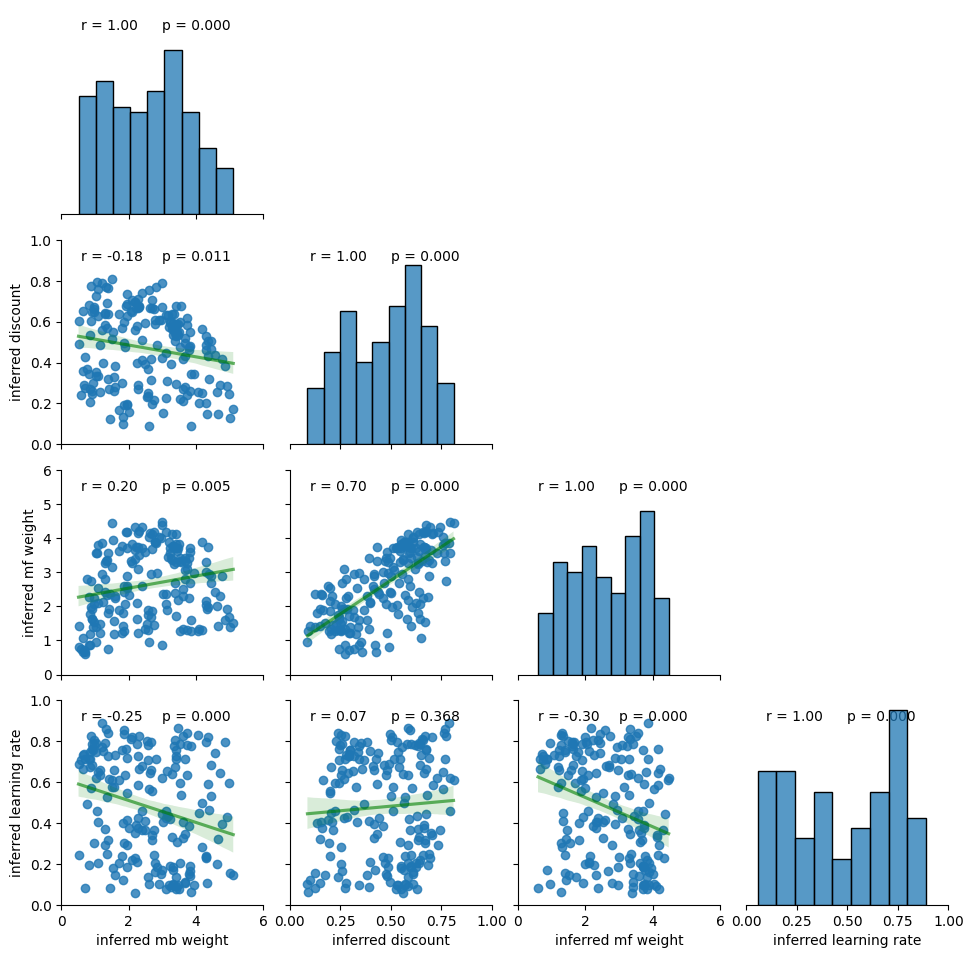

In [18]:
if run_inference:

    # remove old inference?
    remove_old = True

    # set up agent
    bayes_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, base_dir, global_experiment_parameters, data["valid"], remove_old=remove_old)

    print('analyzing '+str(n_agents)+' data sets')

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    num_particles = 15


    print("this is inference using", type(inferrer))
    
    size_chunk = 100
    total_num_iter_so_far = 0

    for i in range(total_num_iter_so_far, num_steps, size_chunk):
        print('taking steps '+str(i+1)+' to '+str(i+size_chunk)+' out of total '+str(num_steps))

        fname_str = fname_base + str(total_num_iter_so_far+size_chunk)+'_'+str(n_agents)+'agents'

        iu.infer(inferrer, size_chunk, fname_str, num_particles, base_dir)
        total_num_iter_so_far += size_chunk

    inferrer.save_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.save_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    # sample from posterior only at last time step and save results. Could be done at every step, if earlier posteriors are of interest, one can load the inferrer save and sample from that.
    mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir, true_vals=true_vals) 

    plt.figure()
    vars_of_interest = ["inferred "+name for name in param_names]
    f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,
                        plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                        grid_kws={"layout_pad": 1.5},
                        x_vars=vars_of_interest, y_vars=vars_of_interest)
    f.map(tu.annot_corrfunc)
    for p, p_range in enumerate(param_ranges):
        f.axes[n_pars-1,p].set_xlim(p_range)
        f.axes[p,0].set_ylim(p_range)
    plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
    plt.show()

<b>Or:</b> Set up agent and inference. Load past inference, decide whether to resample posterior or used stored samples

In [19]:

if not run_inference:

    # set up agent
    mfmb_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, base_dir, global_experiment_parameters, data["valid"], remove_old=False)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(mfmb_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir, true_vals=true_vals) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 


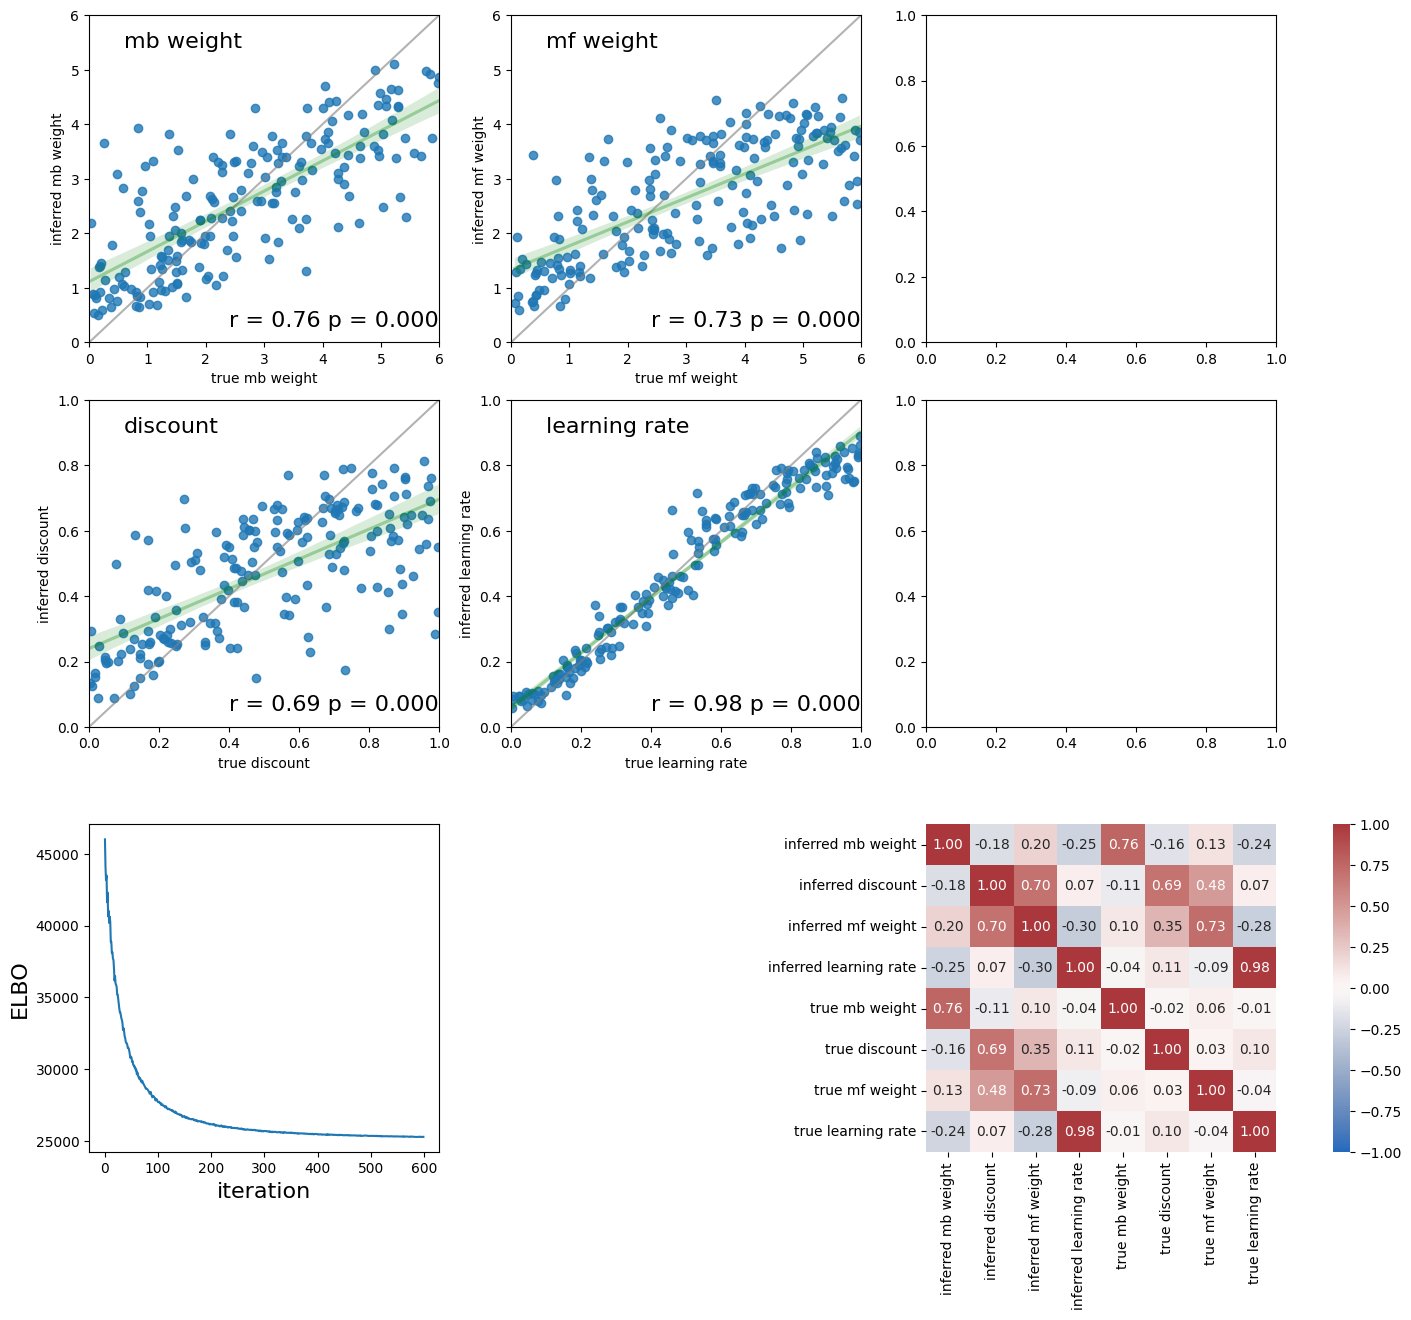

<Figure size 640x480 with 0 Axes>

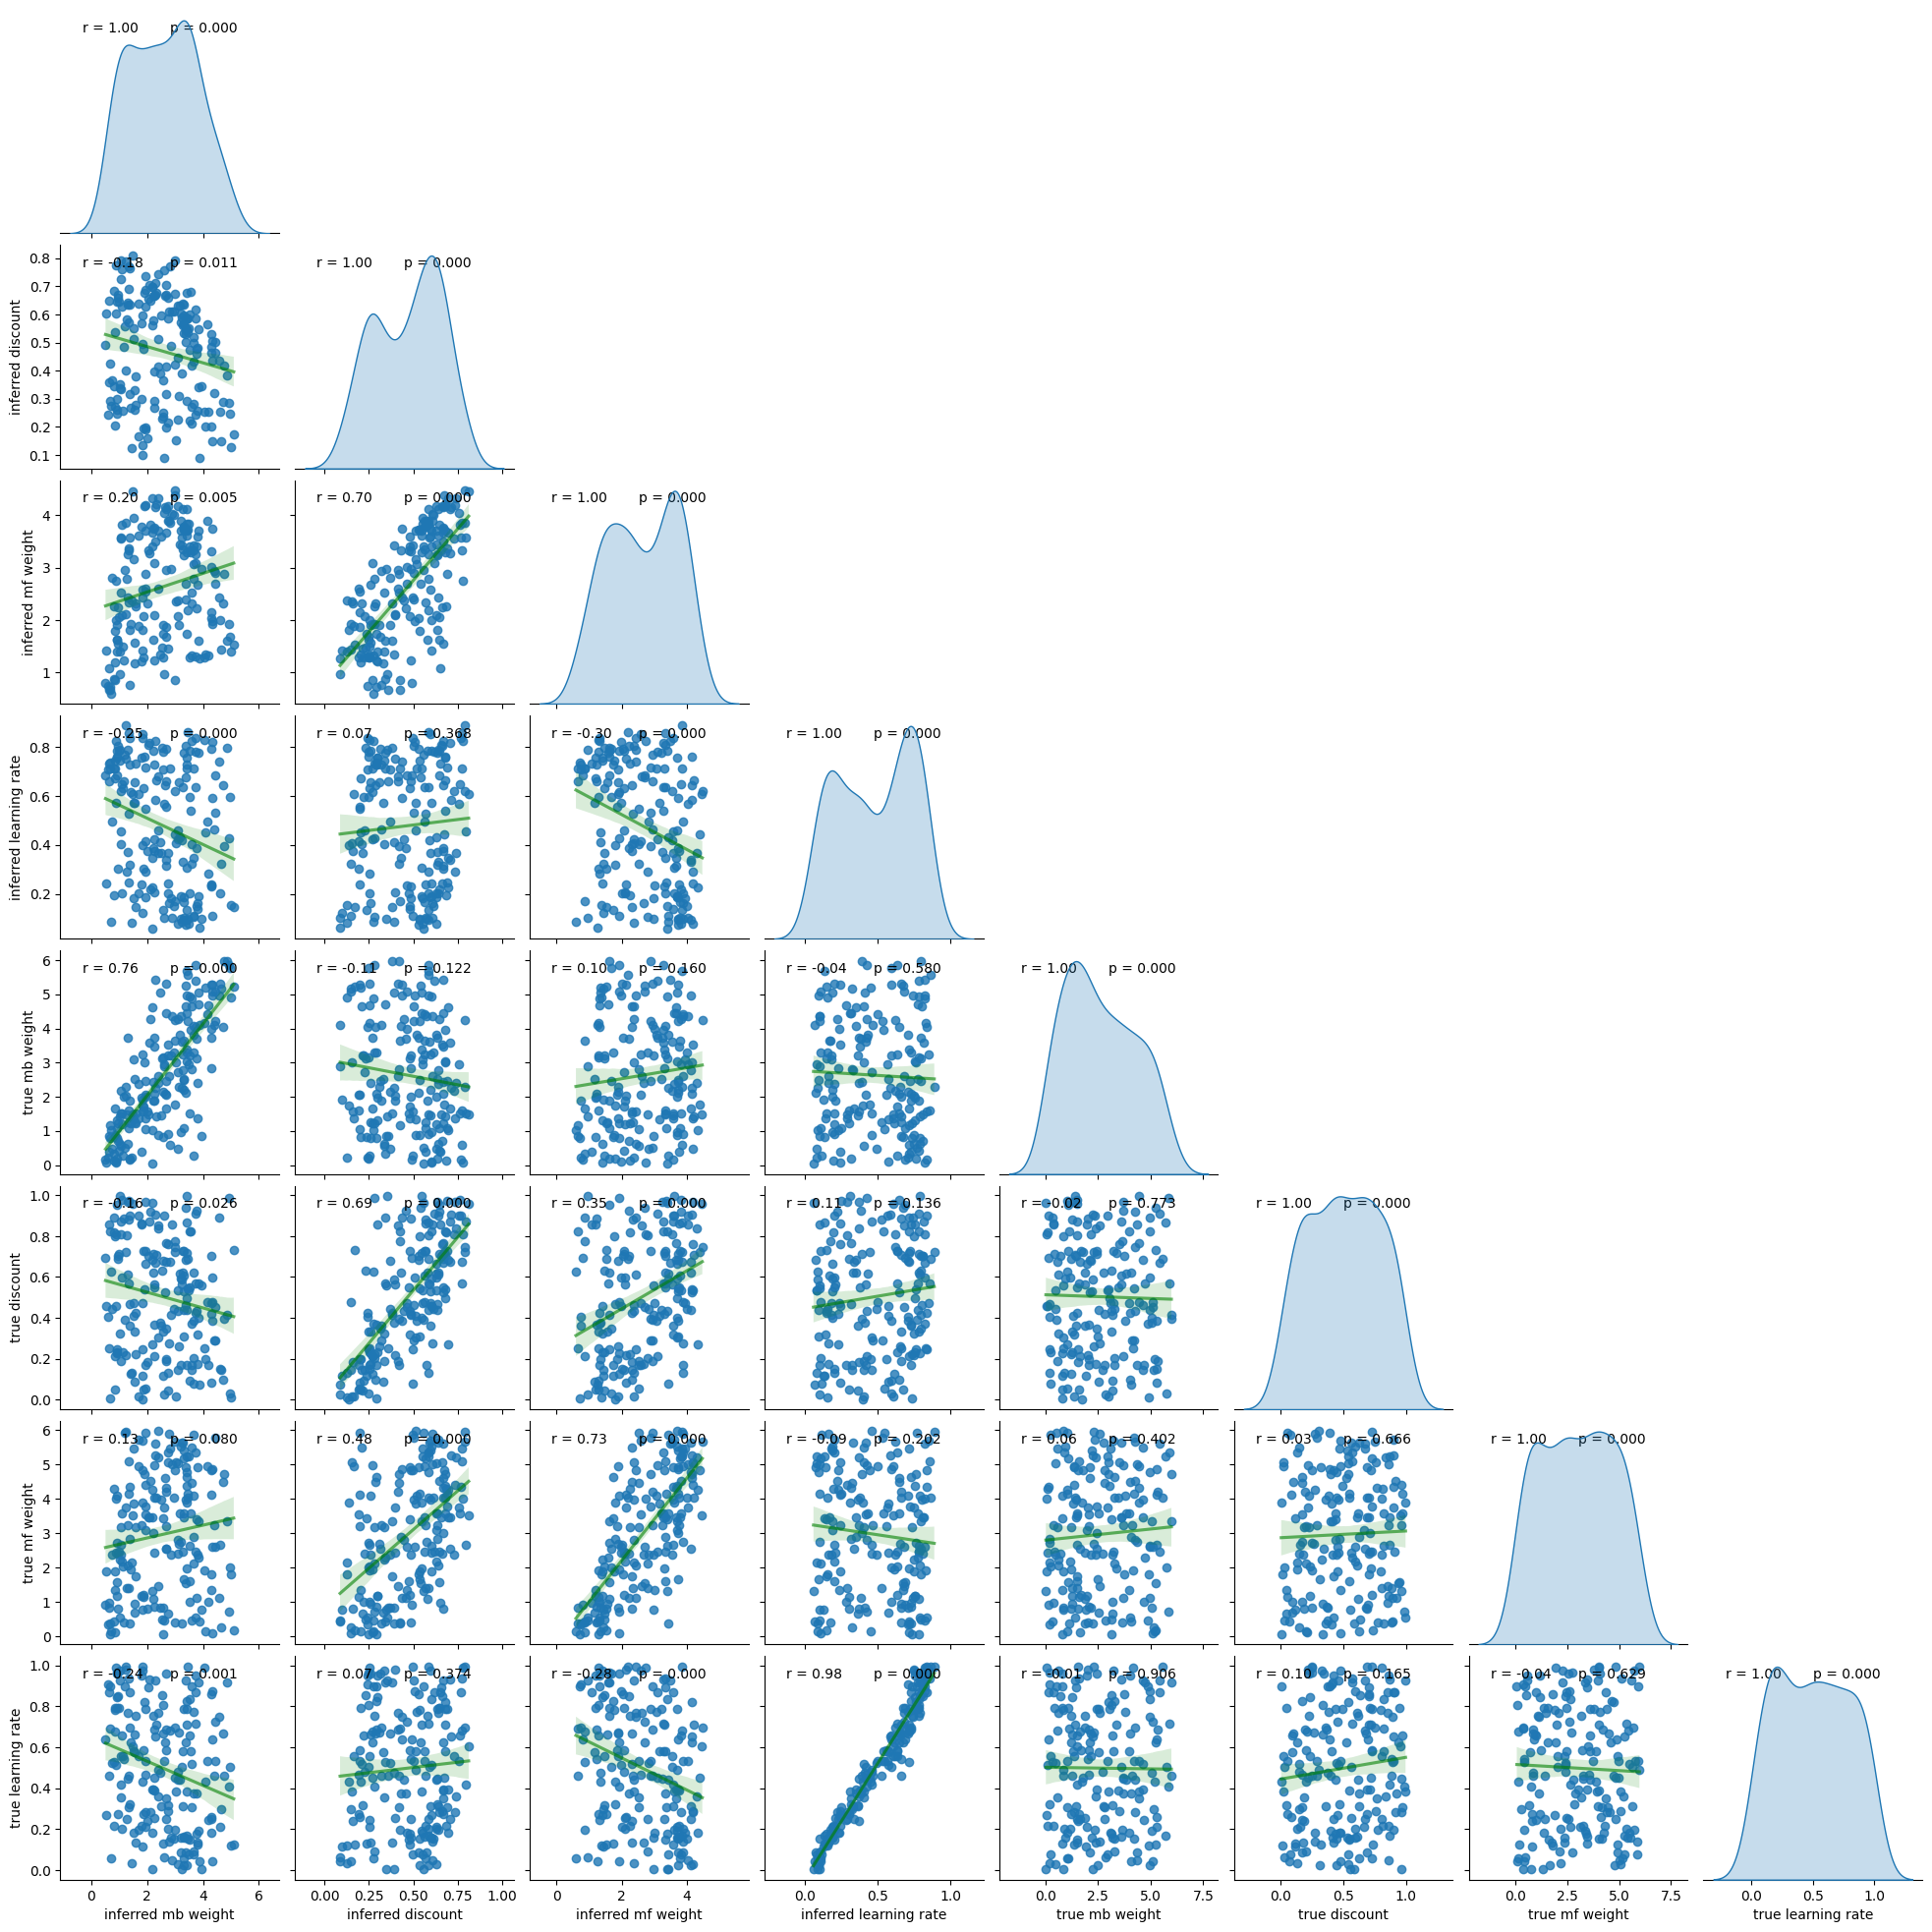

<Figure size 640x480 with 0 Axes>

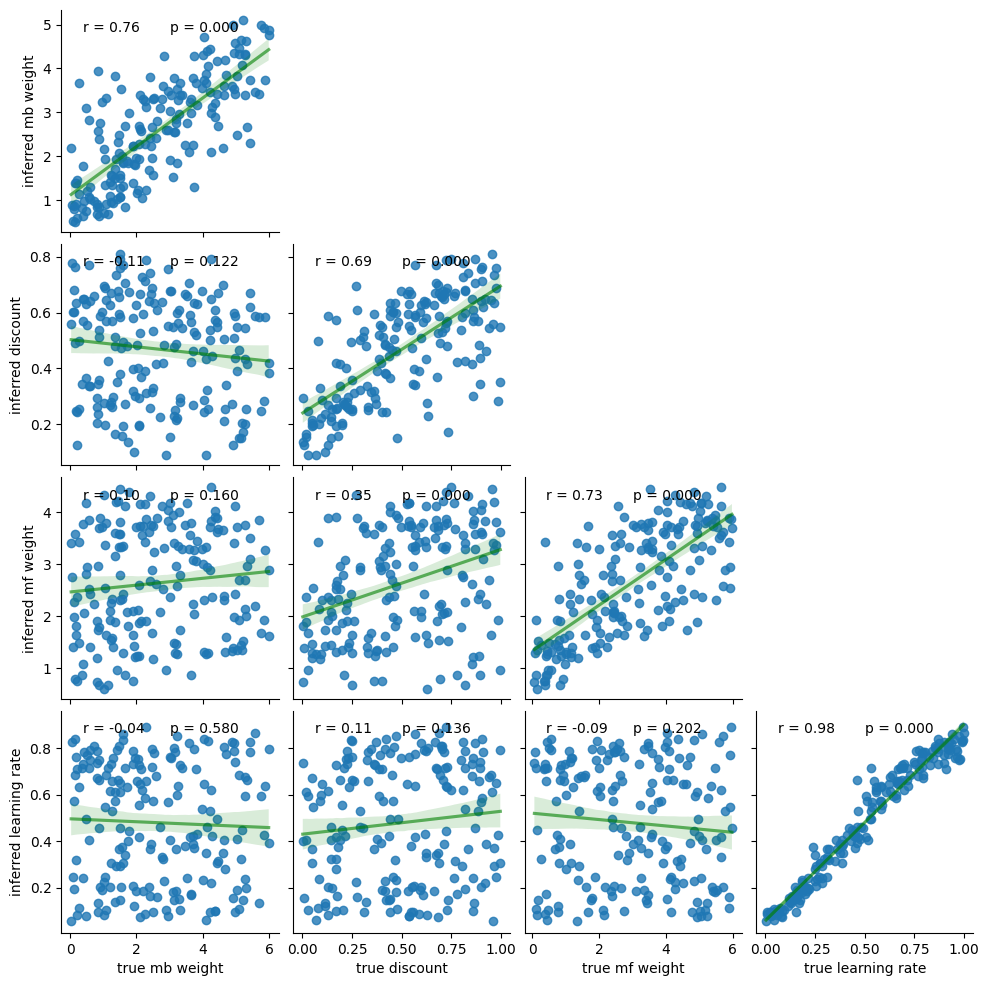

<Figure size 640x480 with 0 Axes>

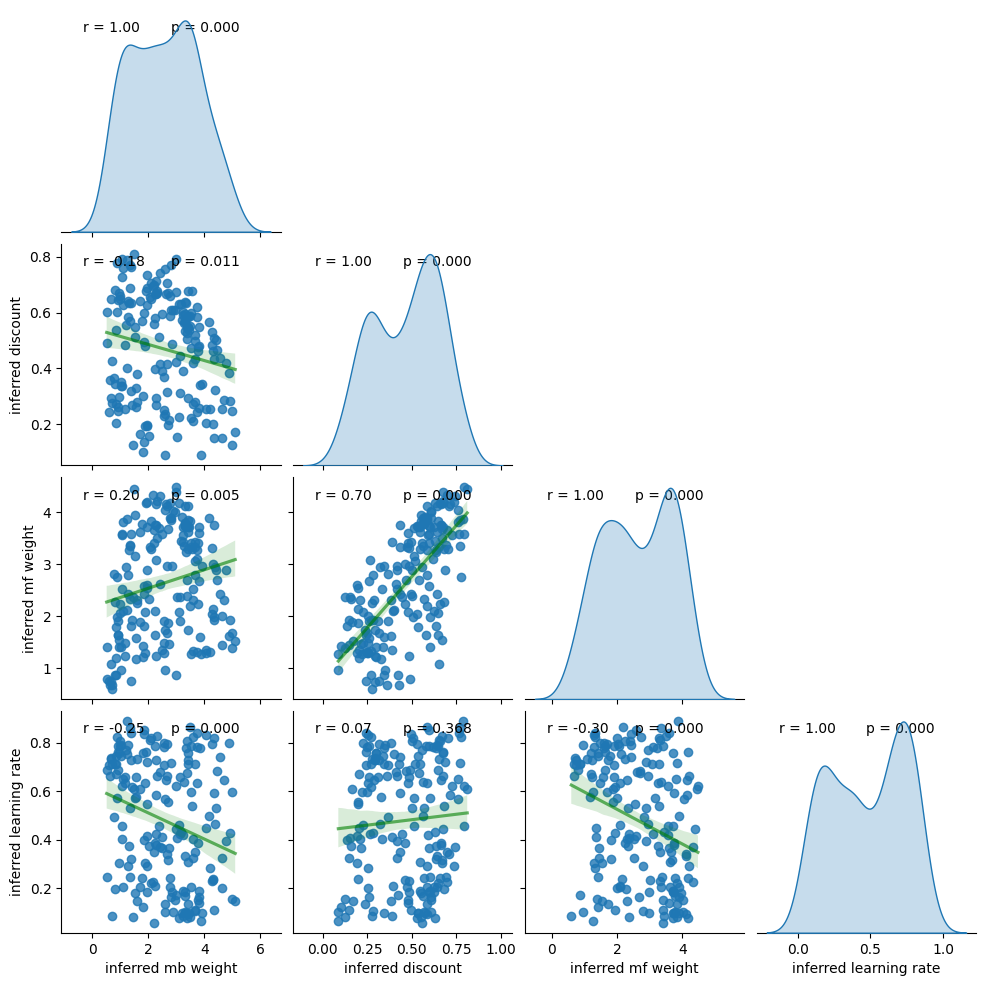

This is recovery for the twostage task using the two beta mbmf model(MFMB_4pars_mf_mb) with 188 agents.
The settings are: infer p False restrict alpha False


In [20]:
iu.plot_results(sample_df, param_names, fname_str, inferrer.loss, mean_df, base_dir, param_ranges)
        
print("This is recovery for the twostage task using the "+model_name+"("+agent_type+")"+" with "+str(n_agents)+" agents.")
print("The settings are: infer p", use_p, "restrict alpha", restrict_alpha)

['true mb weight', 'true discount', 'true mf weight', 'true learning rate']


<Figure size 640x480 with 0 Axes>

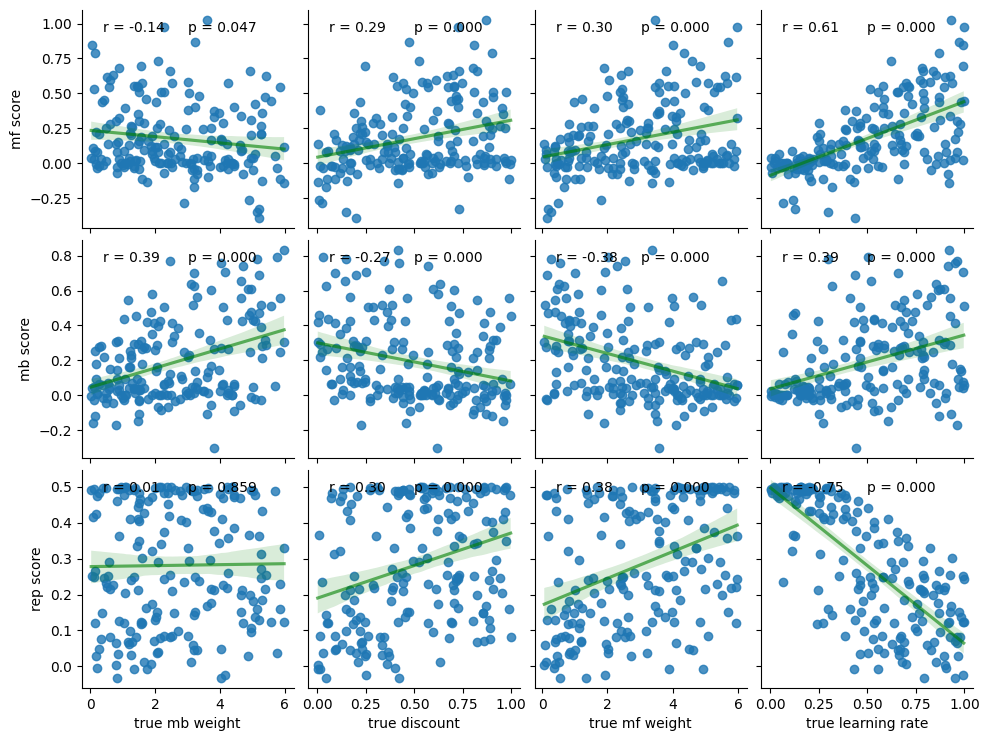

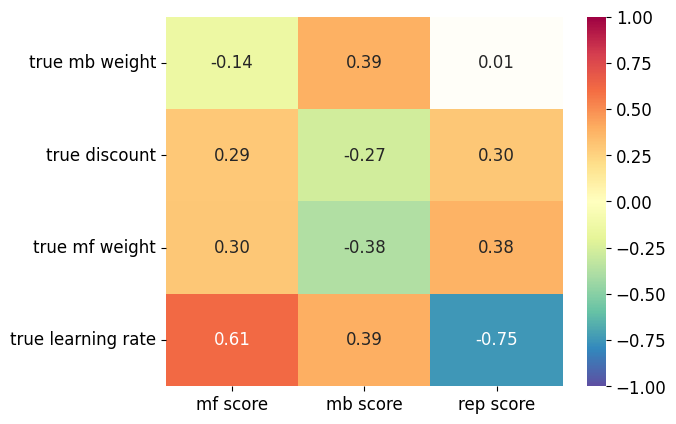

In [21]:
mean_scores_df = pd.concat([mean_df, scores_df], axis='columns')#, join="inner")

plt.figure()
x_vars_of_interest = ["true "+name for name in param_names]
print(x_vars_of_interest)
y_vars_of_interest = list(scores_df.keys())
f = sns.pairplot(data=mean_scores_df, kind='reg', #diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=x_vars_of_interest, y_vars=y_vars_of_interest)
f.map(tu.annot_corrfunc)
#for p, p_range in enumerate(param_plot_ranges):
#    f.axes[2,p].set_xlim(p_range)
#    f.axes[p,0].set_ylim(p_range)
#plt.title("BCC3 analysis 1 correlations with scores")
plt.show()

iu.plot_correlations(mean_scores_df, x_vars_of_interest, y_vars_of_interest)

['inferred mb weight', 'inferred discount', 'inferred mf weight', 'inferred learning rate']


<Figure size 640x480 with 0 Axes>

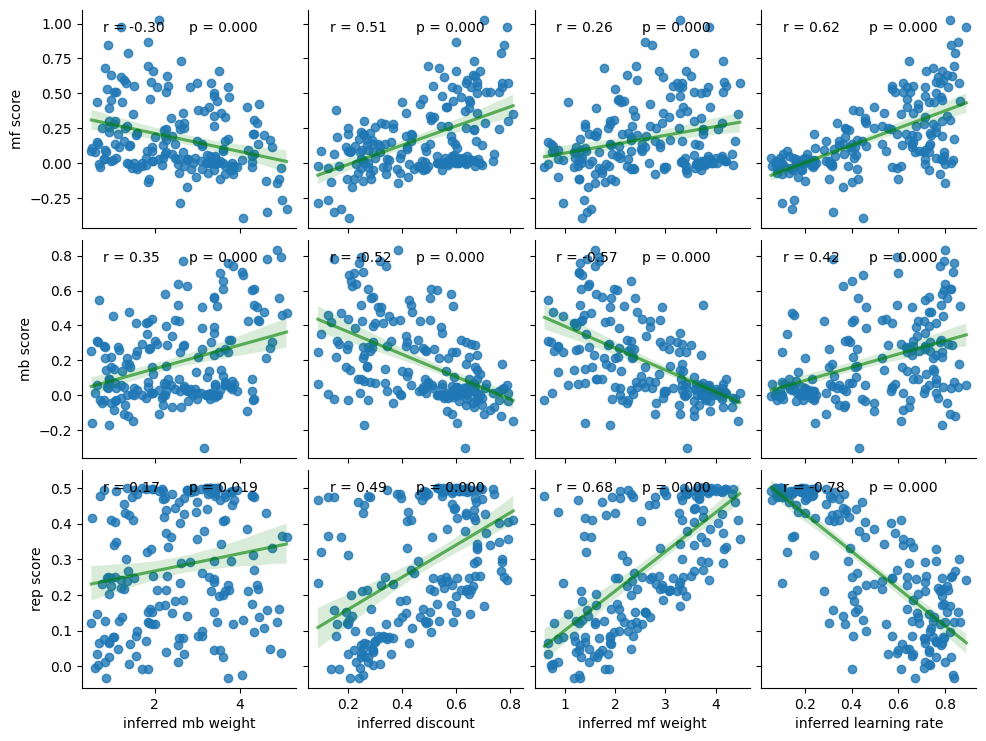

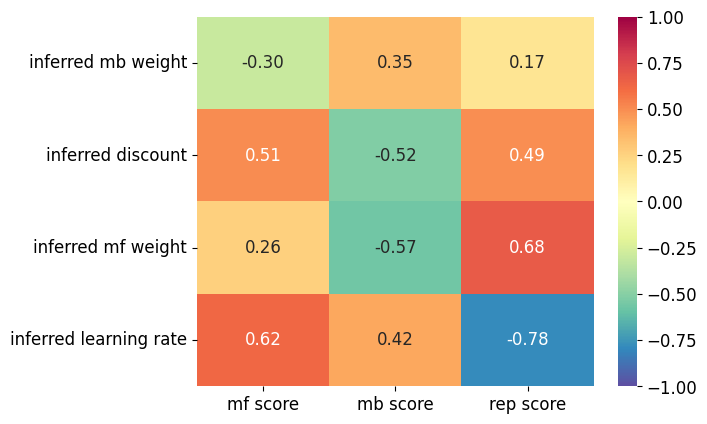

In [22]:
mean_scores_df = pd.concat([mean_df, scores_df], axis='columns')#, join="inner")

plt.figure()
x_vars_of_interest = ["inferred "+name for name in param_names]
print(x_vars_of_interest)
y_vars_of_interest = list(scores_df.keys())
f = sns.pairplot(data=mean_scores_df, kind='reg', #diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=x_vars_of_interest, y_vars=y_vars_of_interest)
f.map(tu.annot_corrfunc)
#for p, p_range in enumerate(param_plot_ranges):
#    f.axes[2,p].set_xlim(p_range)
#    f.axes[p,0].set_ylim(p_range)
#plt.title("BCC3 analysis 1 correlations with scores")
plt.show()

iu.plot_correlations(mean_scores_df, x_vars_of_interest, y_vars_of_interest)